# The recall-workload curve: what a higher `z` costs, and what it buys

**The question this answers.** `tm_threshold_axis_sweep_largest_cc_high_z.ipynb` (*high_z*)
asks how high `z` can go **before a single mitosis is lost** and answers it exactly:
`z_max` = the lowest `z` among the deep pool's TP-bucketed detections. That is a binary
criterion, and it makes the deliverable a *minimum* -- over mitoses, then over clicks, then
over domains -- the shape `DECISIONS.md` D4 rejects depth metrics for (*"unbounded and hostage
to single objects"*). high_z's own numbers show the cost: a global cutoff at `z = 1.308`
removes only ~10% of the candidate pool.

**Why recall@K cannot be used to pick the threshold, on this axis.** high_z measures
`recall_at_budget` on `tm_score` at three cutoffs across 35 (ROI, seed) cells and 8 budgets,
and it is identical in **280/280** of them. That is forced, not luck: every cutoff at or below
`z_max` retains *every* true positive, so truncation deletes only non-TP tail and the top-K
cannot move. Adding recall@K as a threshold-selection axis would produce a table that is flat
by construction.

**What is not flat** is the pair **(candidates retained, recall achieved)** as the cutoff
rises *through and past* `z_max`. This notebook measures that curve over 5 clicks on each of
14 ROIs and reads it three ways:

| reading | fix | report | section |
|---|---|---|---|
| **tolerance** | a recall target `t` | the highest safe `z`, and the pool it leaves | Tables 1 / 1b |
| **budget** | a list length `K` | the recall achieved | Table 3 (D4's recall@K) |
| **reading depth** | a recall target `t` | how far down the list a reader must go | Table 4 |

They are the *same step function*. `compare._read_depths` already computes six of its points
(`read_50` ... `read_100`) and `evaluate.recall_at_k` another reading; neither is stored over
seeds anywhere in this repo, and nothing stores the curve itself.

## What changed from high_z

* **14 ROIs, not 7.** `images/extra_valid` -- 2 per tumour type over all 7 domains, the set D5
  names. high_z ran one ROI per domain, which left the *ROI* half of D4's "worst ROI, worst
  click, per domain" rule untested while D4's stated reason for the rule is precisely that
  ROIs cluster by tumour type. All 7 of high_z's ROIs are inside this 14, so its `z_max` must
  reproduce **bit-for-bit** -- the first gate below.
* **`tm_score` only.** D5 keeps `chromatin_od` off the arbiter, and high_z showed the one
  advantage it had disappears at every deployable cutoff. It is not computed here.
* **A rank ledger instead of a z grid.** `recall_workload_ledger.py` records each mitosis's
  **rank in its own score-descending deep pool**. Because the curve is a step function that
  changes value only at a true positive, those `m` ranks per cell are a *lossless* record of it
  at every achievable operating point -- so every number below is exact, with no grid
  interpolation anywhere.
* **Leave-one-domain-out.** Every cutoff here is still fitted to these ROIs' labels. The LODO
  section picks the cutoff on 6 domains and reports what it achieves on the 7th.

## Read this before reading any number below

* **Cutoffs are FLOORED to the shipped precision, never rounded.** Each is defined as a
  minimum; `round(1.6657, 1) = 1.7` sits *above* the measured safe cutoff and drops a mitosis.
  Every table evaluates its retained count, coverage and recall **at the floored value that
  would actually be deployed**.
* **`coverage_frac` gates every recall number here, and it is not flattering.**
  `evaluate.py` requires it before any un-budgeted recall figure, and Tables 1, 1b, 2 and LODO
  are all un-budgeted. It is reported beside every one of them. At the shipped global cutoff it
  is still high, so `recall_worst = 1.0000` there is substantially a statement of geometry --
  exactly as it was at `z = 1.0`. **Table 4 is only partly exempt, not exempt.** A reading depth
  is `min{K : recall@K >= t}`, the *inverse* of the curve coverage gates, so saturation does not
  merely muddy it: a denser list lowers the best rank near every mitosis, the target is reached
  sooner, and the depth reads **shorter** than the evidence warrants. Table 4 therefore carries
  its own coverage column.
* **Where a worst cell and a median ROI disagree, both are printed.** D4's rule is worst ROI,
  worst click, and every safety number here obeys it. Table 4's headline saving is a
  *median-ROI* statement and the same trade at the worst cell is about half as large, so that
  table reports both and the summary quotes both.
* **Aggregation is per ROI, then across ROIs.** The design is nested -- 2 ROIs x 5 clicks --
  and the per-ROI clusters frequently do not overlap, so a pooled 10-cell median lands in the
  *gap between the two ROIs* and describes no cell that exists. Medians are therefore taken
  within an ROI (over its **distinct** draws) and then reported as a range across ROIs.
* **A minimum still carries no margin.** The tolerance axis relaxes only the innermost minimum
  -- over mitoses. The aggregation across cells is still a hard min, and most global rows are
  set by a single cell. LODO is the only section here that tests generalisation rather than fit.
* **`z` is deployable, `z_max` is not.** `z = (score - median) / mad_scale` comes from the
  response map alone, so a fixed `z` is a real inference-time setting. `z_max` requires knowing
  where the mitoses are.

In [1]:
import time
NB_T0 = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

# `float_precision='round_trip'` on EVERY read. pandas' default C float parser is not
# round-trip exact: on this ledger it returns a value 1 ulp above the written one for 659 of
# 6555 rows. Every cutoff here is a float taken from one of these files and compared with `>=`
# against the same number stored elsewhere, so a 1-ulp drift silently drops the binding
# mitosis -- the same failure mode as storing the pool as float32.
RC = dict(float_precision='round_trip')
CELLS = pd.read_csv('results/tm_recall_workload_cells.csv', **RC)
LED = pd.read_csv('results/tm_recall_workload_tp_ledger.csv', **RC)
POOL = np.load('results/tm_recall_workload_pool_z.npz')
COV = np.load('results/tm_recall_workload_coverage.npz')   # recall_workload_coverage.py

KEY = ['file_name', 'seed_index']
cell_ix = CELLS.set_index(KEY).sort_index()
# Keys normalised to (str, int) so the artefacts -- a MultiIndex, a groupby and two npz name
# spaces -- all address a cell by the same object, whatever dtype each landed on.
KEYS = [(str(a), int(b)) for a, b in cell_ix.index]
POOLZ = {k: POOL[f'{k[0]}|{k[1]}|z'] for k in KEYS}          # descending, float64
LEDG = {(str(a), int(b)): g.sort_values('rank')
        for (a, b), g in LED.groupby(KEY)}                   # rank ascending == z descending
COV_CUM = {k: COV[f'{k[0]}|{k[1]}|cum'] for k in KEYS}
COV_N = {k: int(COV[f'{k[0]}|{k[1]}|n_probes']) for k in KEYS}
assert set(LEDG) == set(KEYS), 'the ledger and the cell table cover different cells'
assert all(len(LEDG[k]) == int(cell_ix.loc[k, 'n_tp_found']) for k in KEYS)
assert all(len(COV_CUM[k]) == int(cell_ix.loc[k, 'n_pool']) + 1 for k in KEYS)

DOMAIN = {k: cell_ix.loc[k, 'tumor_type'] for k in KEYS}
DOMAINS = sorted(CELLS['tumor_type'].unique())
ROIS = sorted(CELLS['file_name'].unique())
ANN = {k: int(cell_ix.loc[k, 'seed_ann_id']) for k in KEYS}

CURRENT_Z = 1.0
SHIP_DP = 1                     # the precision a cutoff is actually shipped at
BUDGETS = (25, 50, 100, 250, 500, 1000, 2000, 5000)
TOLERANCES = (1.00, 0.99, 0.98, 0.95, 0.90)
GLOBAL = '** GLOBAL (all 14 ROIs) **'

nd = CELLS.groupby('file_name')['seed_ann_id'].nunique()
n_seeds = CELLS['seed_index'].nunique()
print(f"{len(CELLS)} (ROI, seed) cells | {len(ROIS)} ROIs x {n_seeds} seeds "
      f"| {len(DOMAINS)} domains | {len(LED)} ledger rows")
print(f"deep_recall == 1.0 in {int((CELLS['deep_recall'] == 1.0).sum())}/{len(CELLS)} cells "
      f"(min {CELLS['deep_recall'].min():.4f})")
print(f"distinct clicks: {int(nd.sum())} of {len(CELLS)} draws -- the draw is WITH replacement "
      f"(high_z's rule, kept so\nthe gate below is meaningful). ROIs with repeats: "
      f"{dict(nd[nd < n_seeds])}. Medians below are taken\nover distinct draws only, so a "
      f"repeated click cannot get double weight; minima use every cell,\nwhere a repeat cannot "
      f"change the answer.")

70 (ROI, seed) cells | 14 ROIs x 5 seeds | 7 domains | 6555 ledger rows
deep_recall == 1.0 in 70/70 cells (min 1.0000)
distinct clicks: 63 of 70 draws -- the draw is WITH replacement (high_z's rule, kept so
the gate below is meaningful). ROIs with repeats: {'094.tiff': 4, '201.tiff': 4, '233.tiff': 3, '300.tiff': 4, '403.tiff': 4, '529.tiff': 4}. Medians below are taken
over distinct draws only, so a repeated click cannot get double weight; minima use every cell,
where a repeat cannot change the answer.


## Gate -- this run reproduces `high_z` on the 7 ROIs they share

`recall_workload_ledger.py` copies high_z's configuration rather than re-deriving it, so on the
7 ROIs both ran, every shared quantity must be **identical**, not close: `z_max` bit-for-bit
(it is a float64 minimum used here as a cut), `n_at_current_z`, and `read_50 ... read_100` for
seed 0 -- re-derived from ledger *ranks* against the values `compare._read_depths` wrote into
high_z's results CSV by a completely different route.

In [2]:
hz_cells = pd.read_csv('results/tm_ccoeff_high_z_seed_table.csv', **RC).set_index(KEY).sort_index()
shared = sorted(set(CELLS['file_name']) & set(hz_cells.index.get_level_values(0)))
mine = cell_ix.loc[cell_ix.index.get_level_values(0).isin(shared)].sort_index()
theirs = hz_cells.loc[hz_cells.index.get_level_values(0).isin(shared)].sort_index()
assert list(mine.index) == list(theirs.index), 'shared (ROI, seed) cells do not line up'

gate = {}
for col in ('z_max', 'map_median', 'mad_scale', 'n_at_current_z', 'n_pool', 'base_size',
            'seed_ann_id', 'n_gt_mitotic'):
    same = bool((mine[col].to_numpy() == theirs[col].to_numpy()).all())
    gate[col] = 'identical' if same else 'DIFFERS'
print(f'{len(shared)} shared ROIs x 5 seeds = {len(mine)} cells, compared bit-for-bit:')
for k, v in gate.items():
    print(f'  {k:16s} {v}')
assert all(v == 'identical' for v in gate.values()), f'this run does not reproduce high_z: {gate}'

hz = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep_largest_cc_high_z.csv', **RC)
hz_deep = (hz[(hz['arm'] == 'tm_score') & (hz['z'] == -1.0)]
           .drop_duplicates('file_name').set_index('file_name'))
bad = 0
for fn in shared:
    g, m = LEDG[(fn, 0)], int(cell_ix.loc[(fn, 0), 'n_gt_mitotic'])
    for frac in (0.5, 0.8, 0.9, 0.95, 0.99, 1.0):
        # `_read_depths` returns a RANK; Tables 1 and 4 cost by `n_at(z)`. The two coincide iff
        # no non-TP candidate ties a mitosis's score -- self-test 2 below measures that directly
        # (0 such ties here), so this gate and those tables are comparing the same quantity.
        want = int(np.ceil(frac * m))                # _read_depths' own convention, verbatim
        v = float(g['rank'].iloc[want - 1]) if want <= len(g) else float('nan')
        ref = float(hz_deep.loc[fn, f'read_{int(round(frac * 100))}'])
        bad += not ((np.isnan(v) and np.isnan(ref)) or np.isclose(v, ref))
print(f"\nread_* re-derived from ledger ranks vs high_z's compare._read_depths: "
      f"{len(shared) * 6} cells, {bad} mismatches")
assert bad == 0, 'the rank ledger disagrees with _read_depths'
print('Gate passed: this is high_z, extended to 14 ROIs.')

7 shared ROIs x 5 seeds = 35 cells, compared bit-for-bit:
  z_max            identical
  map_median       identical
  mad_scale        identical
  n_at_current_z   identical
  n_pool           identical
  base_size        identical
  seed_ann_id      identical
  n_gt_mitotic     identical

read_* re-derived from ledger ranks vs high_z's compare._read_depths: 42 cells, 0 mismatches
Gate passed: this is high_z, extended to 14 ROIs.


## The primitives -- one step function, read four ways

Everything below comes from four exact operations. No grid, no interpolation.

* `n_at(cell, z)` -- candidates retained, via `searchsorted` into that cell's score-descending
  `z` array.
* `tp_kept(cell, z)` -- mitoses retained, in pure integer arithmetic: the pool is z-descending,
  so `{z' >= z}` is exactly its first `n_at(z)` rows and a mitosis is inside iff its rank is.
* `cutoff_for(cell, want)` -- the highest cutoff retaining `want` mitoses, and the list length
  it delivers.
* `coverage(cell, z)` / `cov_at(cell, n)` -- the fraction of the ROI within a match radius of
  some retained detection, addressed by cutoff or by list length, from
  `recall_workload_coverage.py`'s precomputed curve. That script gates itself cell-by-cell at
  four points on each curve against `evaluate.coverage_fraction`, so this is that function's
  value, not an approximation of it. `coverage_fraction` costs ~0.27 s per call and this
  notebook needs it at over seventeen thousand (cell, cutoff) pairs -- Table 2's z sweep alone
  is 70 x 151 = 10,570 -- so the curve turns over an hour per re-read into a lookup. The
  notebook counts its own calls and prints the exact total at the end of the run, so that
  figure cannot go stale.

`want` is `ceil(t*m)` in **integer** arithmetic, exact by construction. This is defensive only:
swept over these tolerances and `m = 1..1000`, the float form `int(np.ceil(t*m))` that
`compare._read_depths` uses **never** disagrees, and self-test 7 re-checks that on the cells
actually present.

In [3]:
def n_at(k, z):
    """Candidates retained by cutoff `z` on cell `k`. Exact: the pool's z is stored float64."""
    return int(np.searchsorted(-POOLZ[k], -float(z), side='right'))


def z_of(k, rank):
    """The z of the `rank`-th candidate. The POOL array is authoritative, never the ledger's
    own `z` column -- one is the number a cutoff is compared against, the other survived a CSV
    round-trip, and they must not be allowed to drift apart."""
    return float(POOLZ[k][rank - 1])


RANKS = {k: LEDG[k]['rank'].to_numpy() for k in KEYS}      # ascending == deepest last


def tp_kept(k, z):
    """Mitoses retained by cutoff `z`, by counting ranks rather than comparing floats."""
    return int((RANKS[k] <= n_at(k, z)).sum())


COV_CALLS = 0                  # printed at the end of the run, so the cost claim above stays true


def cov_at(k, n):
    """`evaluate.coverage_fraction` of the TOP-`n` list. O(1) from the stored curve."""
    global COV_CALLS
    COV_CALLS += 1
    return float(COV_CUM[k][int(n)]) / COV_N[k]


def coverage(k, z):
    """The same number, addressed by cutoff rather than by list length."""
    return cov_at(k, n_at(k, z))


def n_want(k, t):
    """Fewest mitoses that satisfy tolerance `t` on cell `k`, in exact integer arithmetic."""
    m = int(cell_ix.loc[k, 'n_gt_mitotic'])
    return -((-int(round(t * 100)) * m) // 100)


def cutoff_for(k, want):
    """(z, list_length) of the highest cutoff retaining `want` mitoses, or None if unreachable.

    The length is `n_at(z)`, NOT the mitosis's own `rank`: a *score cutoff* cannot hand over
    `rank` candidates while non-TP candidates tie that score at the boundary. `extract_peaks`'
    docstring records that such ties are real, so the distinction is not hypothetical.
    """
    if want <= 0:
        return float('inf'), 0
    if want > len(RANKS[k]):
        return None                      # the deep pool never found that many
    z = z_of(k, int(RANKS[k][want - 1]))
    return z, n_at(k, z)


def read_depth(k, t):
    """List length a reader must take to reach recall `t` on `k`, or None if unreachable.

    Every caller goes through this instead of indexing `cutoff_for(...)[1]`, so an unreachable
    cell surfaces as a None to be handled rather than as a TypeError.
    """
    c = cutoff_for(k, n_want(k, t))
    return None if c is None else c[1]


def ship(z, dp=None):
    """FLOOR a cutoff to the shipped precision. Never round: these are minima, and
    `round(1.6657, 1) = 1.7` sits above the measured safe value and drops a mitosis."""
    dp = SHIP_DP if dp is None else dp
    return float(np.floor(float(z) * 10 ** dp) / 10 ** dp)


def per_roi(keys, f):
    """`f` summarised per ROI: the median over that ROI's DISTINCT draws.

    Two defects are closed here at once. (i) The design is nested -- 2 ROIs x 5 clicks -- and
    the per-ROI clusters often do not overlap, so a pooled 10-cell median is the midpoint of
    the 5th and 6th order statistics, i.e. the midpoint of the ROI *gap*, describing no cell
    that exists. (ii) The draw is with replacement, so a repeated annotation would carry double
    weight in a pooled median. Minima and maxima still use every cell, where neither matters.

    A median over exactly TWO values is that same midpoint trap one level up, so nothing in
    this notebook medians across a domain's two ROIs: callers report `lo` and `hi` instead.
    """
    out = {}
    for fn in sorted({k[0] for k in keys}):
        seen, vals = set(), []
        for k in sorted(kk for kk in keys if kk[0] == fn):
            if ANN[k] in seen:
                continue
            seen.add(ANN[k])
            v = f(k)
            if v is not None:
                vals.append(v)
        out[fn] = float(np.median(vals)) if vals else float('nan')
    return out


# --- self-tests. Each closes a different way the ledger could be wrong.
tie_rows = drift = notch_not_1 = float_disagree = 0
for k in KEYS:
    m = int(cell_ix.loc[k, 'n_gt_mitotic'])
    n_tp = int(cell_ix.loc[k, 'n_tp_found'])
    r = RANKS[k]
    # 1. the pool array really is z-descending -- everything else assumes it
    assert bool(np.all(np.diff(POOLZ[k]) <= 0)), f'{k}: pool z is not descending'
    # 2. cutting at a mitosis's own z retains at least its rank; more only under a score tie
    n_here = np.array([n_at(k, z_of(k, int(rr))) for rr in r])
    assert (n_here >= r).all(), f'{k}: n_at is below a mitosis rank -- pool order is wrong'
    tie_rows += int((n_here > r).sum())
    # 3. the ledger's z column still agrees with the pool array bit-for-bit. This is what fails
    #    without float_precision='round_trip', and it fails silently.
    drift += int((LEDG[k]['z'].to_numpy() != np.array([z_of(k, int(rr)) for rr in r])).sum())
    # 4. the deepest mitosis defines z_max, and cutting there keeps every one the pool found
    zmax = z_of(k, int(r.max()))
    assert zmax == float(cell_ix.loc[k, 'z_max']), f'{k}: z_max disagrees with the pool array'
    assert tp_kept(k, zmax) == n_tp and cutoff_for(k, n_tp)[0] == zmax, f'{k}: z_max is wrong'
    # 5. one notch above z_max must lose the binding mitosis
    lost = n_tp - tp_kept(k, np.nextafter(zmax, np.inf))
    assert lost >= 1, f'{k}: z_max is not binding'
    notch_not_1 += (lost != 1)
    # 6. every mitosis sits inside the CURRENT operating list, so the whole curve is reachable
    #    without ever lowering z below 1.0
    assert int(r.max()) <= int(cell_ix.loc[k, 'n_at_current_z']), \
        f'{k}: a mitosis ranks below the z=1.0 list'
    # 7. n_want is the true ceiling, and the float form it replaces is measured, not assumed
    for t in TOLERANCES:
        w = n_want(k, t)
        assert w >= t * m - 1e-12 and (w - 1) < t * m, f'{k} t={t}: n_want is not ceil(t*m)'
        float_disagree += (w != int(np.ceil(t * m)))
    # 8. the coverage curve is a cdf in list length, over the whole pool
    n_pool = int(cell_ix.loc[k, 'n_pool'])
    cc = COV_CUM[k]
    assert cc[0] == 0 and bool(np.all(np.diff(cc) >= 0)) and cc[-1] <= COV_N[k], \
        f'{k}: coverage curve is not a cdf'
    assert cov_at(k, n_pool) >= cov_at(k, n_at(k, 3.0)) >= cov_at(k, 0) == 0.0, \
        f'{k}: coverage is not monotone in the cutoff'

assert drift == 0, f'{drift} ledger z values drifted from the pool array -- check read_csv'
assert notch_not_1 == 0, f'{notch_not_1} cells lose != 1 mitosis one notch above z_max'
print(f'8 self-tests pass on every one of the {len(KEYS)} cells '
      f'({int(CELLS["n_tp_found"].sum())} mitoses checked individually).')
print(f"  ledger z vs pool array: {drift} drifted (without float_precision='round_trip': 659)")
print(f"  boundary score ties: {tie_rows} mitoses -- where non-zero the delivered list is "
      f"longer than\n  that mitosis's rank, which is why every table costs a cutoff by n_at(z) "
      f"and never by rank.")
print(f'  integer vs float ceil(t*m): {float_disagree} of {len(KEYS) * len(TOLERANCES)} '
      f'(cell, tolerance) pairs disagree.')
print(f'  coverage_frac at z=1.0 spans {min(coverage(k, 1.0) for k in KEYS):.3f}-'
      f'{max(coverage(k, 1.0) for k in KEYS):.3f} across the 70 cells.')

8 self-tests pass on every one of the 70 cells (6555 mitoses checked individually).
  ledger z vs pool array: 0 drifted (without float_precision='round_trip': 659)
  boundary score ties: 0 mitoses -- where non-zero the delivered list is longer than
  that mitosis's rank, which is why every table costs a cutoff by n_at(z) and never by rank.
  integer vs float ceil(t*m): 0 of 350 (cell, tolerance) pairs disagree.
  coverage_frac at z=1.0 spans 0.704-0.998 across the 70 cells.


## Does the second ROI in a domain agree with the first? (The reason for 14.)

This is the D4 gap the scope expansion exists to close, and it has to be looked at *before* the
per-domain tables, because those aggregate the two ROIs together and a per-domain cutoff is by
construction fitted to whichever of the two happens to be worse.

For each ROI, the cutoff its own **worst click** licenses at each tolerance. Then, per domain:

* `roi_gap` -- how far apart the two ROIs are.
* `worst_click_spread` -- the larger of the two ROIs' own click-to-click ranges.

**If `roi_gap > worst_click_spread`, which ROI you drew matters more than which cell you
clicked** -- and a one-ROI-per-domain study could not have seen it.

In [4]:
rows = []
for fn in ROIS:
    ks = sorted(k for k in KEYS if k[0] == fn)
    for t in TOLERANCES:
        cs = {k: cutoff_for(k, n_want(k, t)) for k in ks}
        ok = [cs[k][0] for k in ks if cs[k] is not None]
        if not ok:
            continue
        # min / max / spread use every cell, where a repeated draw cannot move them; the MEDIAN
        # uses distinct draws only, so a click drawn twice does not get two votes.
        seen, med_vals = set(), []
        for k in ks:
            if cs[k] is None or ANN[k] in seen:
                continue
            seen.add(ANN[k])
            med_vals.append(cs[k][0])
        rows.append({'tumor_type': DOMAIN[ks[0]], 'file_name': fn, 'tolerance': t,
                     'n_gt_mitotic': int(cell_ix.loc[ks[0], 'n_gt_mitotic']),
                     'z_worst_click': round(float(min(ok)), 3),
                     'z_median_click': round(float(np.median(med_vals)), 3),
                     'z_best_click': round(float(max(ok)), 3),
                     'click_spread': round(float(max(ok) - min(ok)), 3),
                     'n_distinct_clicks': len(med_vals),
                     'unreachable_clicks': sum(c is None for c in cs.values())})
ROI_T = pd.DataFrame(rows)
ROI_T.to_csv('results/tm_recall_workload_by_roi.csv', index=False)

cmp = (ROI_T.groupby(['tumor_type', 'tolerance'])
       .agg(roi_lo=('z_worst_click', 'min'), roi_hi=('z_worst_click', 'max'),
            worst_click_spread=('click_spread', 'max'), n_rois=('file_name', 'nunique'))
       .reset_index())
cmp['roi_gap'] = (cmp['roi_hi'] - cmp['roi_lo']).round(3)
cmp['roi_axis_dominates'] = cmp['roi_gap'] > cmp['worst_click_spread']

print('Per-ROI cutoff at each tolerance (worst click within that ROI):')
print(ROI_T.pivot_table(index=['tumor_type', 'file_name'], columns='tolerance',
                        values='z_worst_click').round(2).to_string())
dom = cmp[cmp['tolerance'] == 1.00]
print(f"\nAt full recall the two ROIs of a domain disagree by "
      f"{dom['roi_gap'].min():.2f}-{dom['roi_gap'].max():.2f} z.")
print(f"The ROI axis outweighs the click axis in "
      f"{int(cmp['roi_axis_dominates'].sum())}/{len(cmp)} (domain, tolerance) cells "
      f"({int(dom['roi_axis_dominates'].sum())}/{len(dom)} at full recall), and NOT uniformly "
      f"within any domain:")
for d, ts in cmp[cmp['roi_axis_dominates']].groupby('tumor_type')['tolerance'].agg(list).items():
    print(f"    {d}: t = {sorted(ts)}  ({len(ts)} of {len(TOLERANCES)} tolerances)")
print()
print(cmp[['tumor_type', 'tolerance', 'roi_lo', 'roi_hi', 'roi_gap',
           'worst_click_spread', 'roi_axis_dominates']].to_string(index=False))

Per-ROI cutoff at each tolerance (worst click within that ROI):
tolerance                                   0.90  0.95  0.98  0.99  1.00
tumor_type                       file_name                              
canine cutaneous mast cell tumor 300.tiff   3.50  3.21  2.64  2.56  1.47
                                 301.tiff   3.18  2.64  2.41  2.26  1.67
canine lung cancer               201.tiff   3.36  2.99  2.99  2.99  2.99
                                 233.tiff   4.15  3.90  3.90  3.90  3.90
canine lymphosarcoma             245.tiff   2.21  1.97  1.63  1.34  1.34
                                 246.tiff   3.55  3.08  2.49  2.48  1.89
canine soft tissue sarcoma       459.tiff   2.75  2.05  1.94  1.88  1.31
                                 460.tiff   3.60  3.22  1.63  1.63  1.63
human breast cancer              013.tiff   9.75  9.13  9.13  9.13  9.13
                                 094.tiff   6.25  5.47  4.08  3.49  3.49
human melanoma                   529.tiff   3.83  3.09  3.09

## Table 1 -- recall tolerance, the cutoff it licenses, and what is left

D4's rule is **worst ROI, worst click, per domain**, so a domain's cutoff at tolerance `t` is
the *minimum* over its 10 cells of the highest cutoff that cell can take; the global cutoff is
the minimum over all 70. Every row is then evaluated at the **floored, shippable** value.

Three columns carry the warnings:

* `recall_worst` is the gate -- it must never fall below `t`.
* `cut_roi_lo/hi` are the group's ROIs' own medians -- each over that ROI's distinct draws --
  reported as a range, never averaged: two ROIs in a domain row, all 14 in the global row.
  Where they are far apart, no single number describes the group. `cut_roi_median` exists only
  where there are more than two ROIs to take it over, i.e. on the global row; on a domain row
  it would be the midpoint of the two and is left blank.
* `cov_roi_lo/hi` is `coverage_frac` at the shipped cutoff. `evaluate.py` requires it before
  any full-list recall number, and these are all full-list. Where it is near 1, `recall_worst`
  is largely geometry -- the list still tiles the ROI.

In [5]:
def eval_group(keys, z_exact, label, idx_col, idx_val, n_unreachable=0):
    """Evaluate one floored cutoff on every cell of a group, aggregating per ROI then across."""
    z_s = ship(z_exact)
    n_now = {k: n_at(k, z_s) for k in keys}
    m = np.array([int(cell_ix.loc[k, 'n_gt_mitotic']) for k in keys])
    kept = np.array([tp_kept(k, z_s) for k in keys])
    cut = per_roi(keys, lambda k: 100 * (1 - n_now[k] / int(cell_ix.loc[k, 'n_at_current_z'])))
    cov = per_roi(keys, lambda k: coverage(k, z_s))
    keep = per_roi(keys, lambda k: n_now[k])
    # A median over the group's ROIs is only meaningful once there are more than two of them:
    # over exactly two it IS their midpoint, which for a domain whose ROIs do not overlap
    # names a value neither ROI is near. Domain rows therefore carry lo/hi and no median.
    med_cut = round(float(np.median(list(cut.values()))), 1) if len(cut) > 2 else np.nan
    return {'group': label, idx_col: idx_val, 'z_exact': round(float(z_exact), 4), 'z_ship': z_s,
            'n_rois': len(cut),
            'cut_roi_lo': round(min(cut.values()), 1), 'cut_roi_hi': round(max(cut.values()), 1),
            'cut_roi_median': med_cut,
            'n_kept_roi_lo': int(min(keep.values())), 'n_kept_roi_hi': int(max(keep.values())),
            'n_kept_worst_cell': int(max(n_now.values())),
            'cov_roi_lo': round(min(cov.values()), 3), 'cov_roi_hi': round(max(cov.values()), 3),
            'recall_worst': round(float((kept / m).min()), 4),
            'mitoses_lost_worst': int((m - kept).max()),
            'unreachable_cells': n_unreachable}


def group_rows(keys, label, spec):
    """spec: (index column, index value, want-per-cell). Unreachable cells cannot vote on the
    cutoff but are still evaluated, so their shortfall shows in `recall_worst` rather than
    vanishing -- and the group row is never blanked, which an earlier version of this did."""
    out = []
    for idx_col, idx_val, want_fn in spec:
        cuts = {k: cutoff_for(k, want_fn(k)) for k in keys}
        reach = [k for k in keys if cuts[k] is not None]
        if not reach:
            out.append({'group': label, idx_col: idx_val, 'z_exact': np.nan, 'z_ship': np.nan,
                        'unreachable_cells': len(keys)})
            continue
        out.append(eval_group(keys, min(cuts[k][0] for k in reach), label, idx_col, idx_val,
                              len(keys) - len(reach)))
    return out


spec_t = [('tolerance', t, (lambda k, t=t: n_want(k, t))) for t in TOLERANCES]
rows = []
for d in DOMAINS:
    rows += group_rows([k for k in KEYS if DOMAIN[k] == d], d, spec_t)
rows += group_rows(KEYS, GLOBAL, spec_t)
T1 = pd.DataFrame(rows)
T1.to_csv('results/tm_recall_workload_tolerance.csv', index=False)

bad = T1[(T1['recall_worst'] < T1['tolerance'] - 1e-9) & (T1['unreachable_cells'] == 0)]
assert len(bad) == 0, f'a floored cutoff misses its own tolerance:\n{bad}'
print('Every floored cutoff still meets its tolerance on its own worst cell; '
      f"{int(T1['unreachable_cells'].fillna(0).sum())} cells were unreachable at any cutoff.\n")

show = ['tolerance', 'z_ship', 'cut_roi_lo', 'cut_roi_hi', 'n_kept_roi_lo', 'n_kept_roi_hi',
        'n_kept_worst_cell', 'cov_roi_lo', 'cov_roi_hi', 'recall_worst', 'mitoses_lost_worst']
for g in list(DOMAINS) + [GLOBAL]:
    print(f'--- {g} ---')
    print(T1[T1['group'] == g][show].to_string(index=False))
    print()

Every floored cutoff still meets its tolerance on its own worst cell; 0 cells were unreachable at any cutoff.

--- canine cutaneous mast cell tumor ---
 tolerance  z_ship  cut_roi_lo  cut_roi_hi  n_kept_roi_lo  n_kept_roi_hi  n_kept_worst_cell  cov_roi_lo  cov_roi_hi  recall_worst  mitoses_lost_worst
      1.00     1.4         9.0         9.4          18495          25338              28084       0.923       0.970        1.0000                   0
      0.99     2.2        27.9        37.3          13625          18120              21410       0.818       0.890        0.9908                   2
      0.98     2.4        33.1        45.2          12645          16362              19843       0.784       0.844        0.9816                   4
      0.95     2.6        38.6        53.1          11652          14513              18108       0.747       0.782        0.9585                   9
      0.90     3.1        52.9        71.1           8952           9029              13528       

### The same table indexed by mitoses given up, not by a percentage

A fractional tolerance means different things on a 17-mitosis ROI and a 238-mitosis one:
`t = 0.99` costs `013.tiff` nothing at all (`ceil(0.99 x 17) = 17`) and `548.tiff` three
annotations. Since D4's objection to depth metrics is that they are *hostage to single
objects*, the count is the more honest index for a mixed-size set. **This is the table to
quote**; the fractional one understates what a tolerance actually costs.

In [6]:
COUNTS = (0, 1, 2, 3, 5)
spec_c = [('mitoses_given_up', c,
           (lambda k, c=c: int(cell_ix.loc[k, 'n_gt_mitotic']) - c)) for c in COUNTS]
rows = []
for d in DOMAINS:
    rows += group_rows([k for k in KEYS if DOMAIN[k] == d], d, spec_c)
rows += group_rows(KEYS, GLOBAL, spec_c)
T1b = pd.DataFrame(rows)
T1b.to_csv('results/tm_recall_workload_tolerance_by_count.csv', index=False)
assert (T1b['mitoses_lost_worst'] <= T1b['mitoses_given_up']).all(), \
    'a cutoff lost more mitoses than its budget allows'

print('Per-ROI mitoses given up; cutoff is worst click AND worst ROI in the group.\n')
print(T1b[T1b['group'] == GLOBAL][
    ['mitoses_given_up', 'z_ship', 'cut_roi_lo', 'cut_roi_median', 'cut_roi_hi',
     'n_kept_worst_cell', 'cov_roi_lo', 'cov_roi_hi', 'recall_worst']].to_string(index=False))
print("\nPer domain -- shipped z, the two ROIs' own median pool cuts, and coverage at the cut:")
print(T1b[T1b['group'] != GLOBAL]
      .pivot_table(index='group', columns='mitoses_given_up',
                   values=['z_ship', 'cut_roi_lo', 'cut_roi_hi', 'cov_roi_hi']).round(2)
      .to_string())

Per-ROI mitoses given up; cutoff is worst click AND worst ROI in the group.

 mitoses_given_up  z_ship  cut_roi_lo  cut_roi_median  cut_roi_hi  n_kept_worst_cell  cov_roi_lo  cov_roi_hi  recall_worst
                0     1.3         6.5             9.7        17.9              36251       0.666       0.994        1.0000
                1     1.6        13.8            19.6        29.1              31852       0.624       0.979        0.9888
                2     1.7        16.0            22.5        32.5              29926       0.613       0.966        0.9714
                3     1.8        18.3            25.6        37.2              27878       0.602       0.947        0.9663
                5     2.0        22.9            32.4        45.9              23346       0.583       0.923        0.9438

Per domain -- shipped z, the two ROIs' own median pool cuts, and coverage at the cut:
                                 cov_roi_hi                         cut_roi_hi                    

## Table 2 -- pushing `z` past `z_max`: recall lost against candidates removed

high_z stops at `z_max`. Everything above it is where the trade-off lives. Recall is aggregated
as **worst over the 10 cells** (D4); volume as the **median over ROI medians**.

Coverage is reported twice, deliberately, because a min and a max are *different cells* and
lining them up under one heading invites reading a row as though it described one:

* `cov_at_worst_recall` -- the coverage of **the very cell whose recall is quoted**. This is the
  one that speaks to the recall number beside it. Where recall is tied -- and below `z_max` it
  is tied at 1.000 across all 70 cells -- the tie goes to the most saturated of the tied cells,
  so the column never reports an arbitrary cell's coverage as the group's.
* `cov_most_saturated` -- the maximum over the group, the worst case for the reading. It equals
  the column above wherever recall is flat, by that tie-break, and diverges once recall starts
  separating cells.

`cut_median_roi` and `cov_median_roi` are populated on the global row only: over a domain's two
ROIs a median is their midpoint, which is the defect the per-ROI aggregation exists to avoid.

Read the coverage row next to the recall row. They decay together, and the domains whose recall
collapses fastest above `z_max` are the domains whose coverage collapses fastest. That does not
refute the recall reading, but it does mean the cliff may be about candidate *density* rather
than about how hard the domain is to discriminate.

In [7]:
Z_SWEEP = np.round(np.arange(1.0, 16.001, 0.1), 2)
rows = []
for k in KEYS:
    m = int(cell_ix.loc[k, 'n_gt_mitotic'])
    n_cur = int(cell_ix.loc[k, 'n_at_current_z'])
    for z in Z_SWEEP:
        kept, n = tp_kept(k, z), n_at(k, z)
        rows.append({'file_name': k[0], 'seed_index': k[1], 'tumor_type': DOMAIN[k], 'z': z,
                     'recall': kept / m, 'mitoses_lost': m - kept, 'n_kept': n,
                     'coverage_frac': cov_at(k, n),
                     'cut_vs_z1_pct': 100 * (1 - n / n_cur)})
SWEEP = pd.DataFrame(rows)
SWEEP.to_csv('results/tm_recall_workload_z_sweep.csv', index=False)

SEL = [1.0, 1.3, 1.5, 2.0, 2.5, 3.0, 4.0, 6.0, 8.0]


def worst_recall_cell(keys, z):
    """The cell a `worst` column quotes: lowest recall, and among ties the most saturated.

    The tie-break is not a formality. Below `z_max` EVERY cell is at recall 1.000, so the
    minimum is a 70-way tie, and breaking it by file name would print one arbitrary cell's
    coverage as though it characterised the group. Ties go to the highest coverage instead --
    the worst case for the reading, which is the conservative choice and makes this column
    agree with `cov_most_saturated` exactly where recall carries no information.
    """
    return min(keys, key=lambda k: (tp_kept(k, z) / int(cell_ix.loc[k, 'n_gt_mitotic']),
                                    -coverage(k, z), k))


rows = []
groups = [(d, [k for k in KEYS if DOMAIN[k] == d]) for d in DOMAINS] + [('** GLOBAL **', KEYS)]
for label, ks in groups:
    for z in SEL:
        kw = worst_recall_cell(ks, z)
        cut = per_roi(ks, lambda k, z=z: 100 * (1 - n_at(k, z)
                                                / int(cell_ix.loc[k, 'n_at_current_z'])))
        cov = per_roi(ks, lambda k, z=z: coverage(k, z))
        rows.append({
            'group': label, 'z': z,
            'recall_worst': tp_kept(kw, z) / int(cell_ix.loc[kw, 'n_gt_mitotic']),
            'worst_cell': f'{kw[0]} s{kw[1]}',
            'cov_at_worst_recall': coverage(kw, z),
            'cov_most_saturated': max(coverage(k, z) for k in ks),
            'lost_worst': int(max(int(cell_ix.loc[k, 'n_gt_mitotic']) - tp_kept(k, z)
                                  for k in ks)),
            'n_rois': len(cut),
            # NaN on a 2-ROI domain row for the reason given in `eval_group`: a two-value
            # median is a midpoint, not a summary.
            'cut_median_roi': float(np.median(list(cut.values()))) if len(cut) > 2 else np.nan,
            'cov_median_roi': (float(np.median(list(cov.values()))) if len(cut) > 2
                               else np.nan)})
T2 = pd.DataFrame(rows)
T2.to_csv('results/tm_recall_workload_z_sweep_summary.csv', index=False)

rnd = {'recall_worst': 4, 'cov_at_worst_recall': 3, 'cov_most_saturated': 3,
       'cut_median_roi': 1, 'cov_median_roi': 3}
print(f'{len(SWEEP)} (cell, z) evaluations over z = 1.0 .. 16.0 step 0.1.\n')
print('GLOBAL at selected cutoffs -- the worst cell, ITS OWN coverage, and the median ROI:')
print(T2[T2['group'] == '** GLOBAL **']
      .drop(columns='group').round(rnd).to_string(index=False))

dom = T2[T2['group'] != '** GLOBAL **']
print('\nPer domain -- worst-cell recall:')
print(dom.pivot_table(index='group', columns='z', values='recall_worst').round(3).to_string())
print('\nPer domain -- coverage OF THAT SAME CELL (matched, not a max over the group):')
print(dom.pivot_table(index='group', columns='z',
                      values='cov_at_worst_recall').round(3).to_string())
print('\nPer domain -- coverage of the most saturated cell (worst case for the reading):')
print(dom.pivot_table(index='group', columns='z',
                      values='cov_most_saturated').round(3).to_string())

10570 (cell, z) evaluations over z = 1.0 .. 16.0 step 0.1.

GLOBAL at selected cutoffs -- the worst cell, ITS OWN coverage, and the median ROI:
  z  recall_worst  worst_cell  cov_at_worst_recall  cov_most_saturated  lost_worst  n_rois  cut_median_roi  cov_median_roi
1.0        1.0000 245.tiff s4                0.998               0.998           0      14             0.0           0.924
1.3        1.0000 245.tiff s4                0.995               0.995           0      14             9.7           0.895
1.5        0.9888 245.tiff s2                0.974               0.988           1      14            16.3           0.868
2.0        0.9438 245.tiff s2                0.839               0.951           5      14            32.4           0.767
2.5        0.7753 245.tiff s2                0.525               0.902          20      14            48.3           0.583
3.0        0.5843 245.tiff s2                0.228               0.800          37      14            63.9           0

## Table 3 -- the same curve read as `recall@K`, and why it cannot pick a threshold

D4's reporting unit. `recall@K` on `tm_score` is `#{mitoses with rank <= K} / m`, off the same
ledger. Two things together, and the pairing is the point:

1. **`recall@K` is exactly invariant to the cutoff for every `z <= z_max`.** Checked on every
   (cell, K, cutoff) triple -- the 14-ROI version of high_z's 280/280. One of the three cutoffs
   tested *is* the baseline, so a third of those comparisons are trivially zero; the
   informative count is reported separately.
2. **The spread it does have is across cells, and it is mostly the ROI, not the click.** The
   two are decomposed here rather than pooled: an earlier version of this notebook called the
   pooled 10-cell range a "click spread" and overstated the click's effect by about 2x.

`roi_gap` is the difference between the two ROIs' medians, and those medians run over each
ROI's **distinct** draws (`per_roi`), so a click drawn twice does not vote twice. The `worst`,
`best` and `max_click_spread` columns are minima and maxima and use every cell, where a repeat
cannot move them.

In [8]:
def recall_at_k(k, K, z=None):
    """Mitoses in the top-K of the list a cutoff `z` produces (None = the full deep pool)."""
    limit = K if z is None else min(K, n_at(k, z))
    return int((RANKS[k] <= limit).sum()) / int(cell_ix.loc[k, 'n_gt_mitotic'])


moved = informative = 0
for k in KEYS:
    zmax = float(cell_ix.loc[k, 'z_max'])
    for z in (CURRENT_Z, 0.5 * (CURRENT_Z + zmax), zmax):
        for K in BUDGETS:
            informative += (z != CURRENT_Z)
            moved += not np.isclose(recall_at_k(k, K, z), recall_at_k(k, K, CURRENT_Z))
print(f'recall@K at three cutoffs spanning [1.0, z_max] x {len(KEYS)} cells x {len(BUDGETS)} '
      f'budgets: {moved} of {len(KEYS) * 3 * len(BUDGETS)} comparisons moved')
print(f'  ({informative} of them are against a different cutoff; the other '
      f'{len(KEYS) * len(BUDGETS)} compare the baseline with itself).')
assert moved == 0, 'recall@K is not cutoff-invariant below z_max -- the prefix identity broke'
print('Zero. Below z_max the threshold cannot touch recall@K.\n')

rows = []
for k in KEYS:
    for K in BUDGETS:
        rows.append({'tumor_type': DOMAIN[k], 'file_name': k[0], 'seed_index': k[1],
                     'budget': K, 'recall_at_k': recall_at_k(k, K)})
RK = pd.DataFrame(rows)
RK.to_csv('results/tm_recall_workload_recall_at_k.csv', index=False)

# Decompose the pooled 10-cell range into a within-ROI (click) part and a between-ROI part.
# min/max use every cell -- a repeat cannot move them. The per-ROI median that feeds `roi_gap`
# goes through `per_roi`, so it runs over DISTINCT draws only.
rows = []
for d in DOMAINS:
    ks_d = [k for k in KEYS if DOMAIN[k] == d]
    rois = sorted({k[0] for k in ks_d})
    for K in BUDGETS:
        med = per_roi(ks_d, lambda k, K=K: recall_at_k(k, K))
        per = {r: [recall_at_k(k, K) for k in ks_d if k[0] == r] for r in rois}
        vals = [v for r in rois for v in per[r]]
        rows.append({'tumor_type': d, 'budget': K,
                     'worst': min(vals), 'best': max(vals),
                     # the two ROI medians as a RANGE -- their median would be their midpoint
                     'roi_med_lo': round(min(med.values()), 3),
                     'roi_med_hi': round(max(med.values()), 3),
                     'cell_spread': round(max(vals) - min(vals), 3),
                     'max_click_spread': round(max(max(per[r]) - min(per[r]) for r in rois), 3),
                     'roi_gap': round(max(med.values()) - min(med.values()), 3)})
pooled = pd.DataFrame(rows)
pooled.to_csv('results/tm_recall_workload_recall_at_k_spread.csv', index=False)

print('recall@K per domain -- worst CELL (D4: worst ROI and worst click):')
print(pooled.pivot_table(index='tumor_type', columns='budget',
                         values='worst').round(3).to_string())
print("\nWithin-ROI spread only -- the genuine CLICK effect (max over the two ROIs):")
print(pooled.pivot_table(index='tumor_type', columns='budget',
                         values='max_click_spread').round(3).to_string())
print("\nBetween-ROI gap -- the two ROIs' distinct-draw medians, differenced:")
print(pooled.pivot_table(index='tumor_type', columns='budget',
                         values='roi_gap').round(3).to_string())
i = pooled['max_click_spread'].idxmax()
j = pooled['roi_gap'].idxmax()
print(f"\nLargest genuine within-ROI CLICK spread anywhere: "
      f"{pooled.loc[i, 'max_click_spread']:.3f} ({pooled.loc[i, 'tumor_type']}, "
      f"K={int(pooled.loc[i, 'budget'])}).")
print(f"Largest between-ROI gap: {pooled.loc[j, 'roi_gap']:.3f} ({pooled.loc[j, 'tumor_type']}, "
      f"K={int(pooled.loc[j, 'budget'])}) -- at that same K the pooled 10-cell range, which "
      f"mixes\nthe two axes, reads {pooled.loc[j, 'cell_spread']:.3f}. The largest pooled range "
      f"anywhere is {pooled['cell_spread'].max():.3f} "
      f"({pooled.loc[pooled['cell_spread'].idxmax(), 'tumor_type']}, "
      f"K={int(pooled.loc[pooled['cell_spread'].idxmax(), 'budget'])}).")
print('The threshold moves recall@K by exactly 0.000; the ROI moves it by more than the click.')

recall@K at three cutoffs spanning [1.0, z_max] x 70 cells x 8 budgets: 0 of 1680 comparisons moved
  (1120 of them are against a different cutoff; the other 560 compare the baseline with itself).
Zero. Below z_max the threshold cannot touch recall@K.



recall@K per domain -- worst CELL (D4: worst ROI and worst click):
budget                             25     50     100    250    500    1000   2000   5000
tumor_type                                                                              
canine cutaneous mast cell tumor  0.069  0.133  0.235  0.389  0.544  0.650  0.779  0.903
canine lung cancer                0.176  0.294  0.353  0.529  0.647  0.824  0.882  1.000
canine lymphosarcoma              0.000  0.000  0.022  0.079  0.169  0.236  0.360  0.652
canine soft tissue sarcoma        0.092  0.169  0.285  0.415  0.515  0.662  0.762  0.877
human breast cancer               0.160  0.294  0.457  0.531  0.679  0.815  0.963  1.000
human melanoma                    0.059  0.130  0.273  0.504  0.684  0.789  0.895  0.947
human neuroendocrine tumor        0.067  0.144  0.231  0.385  0.462  0.712  0.827  0.971

Within-ROI spread only -- the genuine CLICK effect (max over the two ROIs):
budget                             25     50     100   

## Table 4 -- reading depth, and how much of it survives the coverage gate

Tables 1, 1b and 2 operate on the **detector's pool**, which runs 12k-36k candidates. Nobody
reads that; the reader takes the top of it. That is why those tables need `coverage_frac`, and
why their savings are compute rather than clinical.

This table asks the product question instead: **how far down the ranked list must a reader go
to reach a recall target?** It is the same step function, read at a third angle -- `read_100`
here is exactly `n_at(z_max)`.

**An earlier version of this notebook claimed the coverage caveat did not apply to this table
at all**, on the grounds that a reading depth is a top-K rather than a full-list statement.
That was wrong, and wrong in the flattering direction. `read_depth(t) = min{K : recall@K >= t}`
is the *inverse* of the curve `coverage_frac` gates: a list dense enough to tile the ROI lowers
the best rank near every mitosis, so the target is reached sooner and the depth reads **shorter**
than the evidence warrants. Coverage is therefore measured at every depth here, and it splits
the table cleanly -- low where the trade is attractive, high in the deepest rows on the ROIs
that need the most reading. Those deep rows are geometry, like the tables above them.

Both aggregations are reported, because they disagree by about a factor of two: `median_roi` is
the median of the 14 ROI medians, `worst_cell` is D4's rule. Per domain, the two ROIs are given
as a range and **never averaged** -- a median over exactly two ROIs is their midpoint, which for
`canine lymphosarcoma` would land ~10,000 candidates from either of them.

In [9]:
READ_T = (0.50, 0.80, 0.90, 0.95, 0.98, 0.99, 1.00)
rows = []
for k in KEYS:
    for t in READ_T:
        n = read_depth(k, t)
        rows.append({'tumor_type': DOMAIN[k], 'file_name': k[0], 'seed_index': k[1],
                     'target': t, 'read_depth': n,
                     'coverage_frac': np.nan if n is None else cov_at(k, n)})
RD = pd.DataFrame(rows)
RD.to_csv('results/tm_recall_workload_reading_depth.csv', index=False)
assert RD['read_depth'].notna().all(), 'a cell cannot reach a target at any depth'

depth_roi = {t: per_roi(KEYS, lambda k, t=t: read_depth(k, t)) for t in READ_T}
cov_roi = {t: per_roi(KEYS, lambda k, t=t: cov_at(k, read_depth(k, t))) for t in READ_T}
worst = {t: max(KEYS, key=lambda k, t=t: (read_depth(k, t), k)) for t in READ_T}
g = pd.DataFrame({
    'target': list(READ_T),
    'median_roi': [int(np.median(list(depth_roi[t].values()))) for t in READ_T],
    'roi_lo': [int(min(depth_roi[t].values())) for t in READ_T],
    'roi_hi': [int(max(depth_roi[t].values())) for t in READ_T],
    'cov_median_roi': [round(float(np.median(list(cov_roi[t].values()))), 3) for t in READ_T],
    'cov_roi_hi': [round(max(cov_roi[t].values()), 3) for t in READ_T],
    'worst_cell': [int(read_depth(worst[t], t)) for t in READ_T],
    'cov_worst_cell': [round(cov_at(worst[t], read_depth(worst[t], t)), 3) for t in READ_T],
}).set_index('target')
g['x_less_median'] = (g.loc[1.00, 'median_roi'] / g['median_roi']).round(1)
g['x_less_worst'] = (g.loc[1.00, 'worst_cell'] / g['worst_cell']).round(1)
print('Candidates a reader must work through to reach a recall target, with the coverage of')
print('the list at that depth -- the gate that says whether the number is evidence or geometry:')
print()
print(g.to_string())

print('\nPer domain -- the two ROIs as a RANGE (never averaged) and the worst cell:')
dom = []
for d in DOMAINS:
    ks = [k for k in KEYS if DOMAIN[k] == d]
    row = {'tumor_type': d}
    for t in (0.90, 0.95, 1.00):
        dr = per_roi(ks, lambda k, t=t: read_depth(k, t))
        row[f'roi_lo@{t:.2f}'] = int(min(dr.values()))
        row[f'roi_hi@{t:.2f}'] = int(max(dr.values()))
        row[f'worst@{t:.2f}'] = int(max(read_depth(k, t) for k in ks))
    dom.append(row)
print(pd.DataFrame(dom).set_index('tumor_type').to_string())

print('\nMarginal cost of the last mitoses -- at the median ROI AND at the worst cell (D4):')
full_m, full_w = int(g.loc[1.00, 'median_roi']), int(g.loc[1.00, 'worst_cell'])
for a in (0.90, 0.95, 0.98, 0.99):
    print(f"  give up {1 - a:.0%}: median ROI {full_m:>6,} -> {int(g.loc[a, 'median_roi']):>6,} "
          f"({g.loc[a, 'x_less_median']:.1f}x less, coverage "
          f"{g.loc[1.00, 'cov_median_roi']:.3f} -> {g.loc[a, 'cov_median_roi']:.3f})  |  "
          f"worst cell {full_w:>6,} -> {int(g.loc[a, 'worst_cell']):>6,} "
          f"({g.loc[a, 'x_less_worst']:.1f}x less, coverage "
          f"{g.loc[1.00, 'cov_worst_cell']:.3f} -> {g.loc[a, 'cov_worst_cell']:.3f})")
print('\nThe saving at the worst cell is roughly half the saving at the median ROI, and the')
print('deepest rows sit at a coverage where the depth is geometry rather than evidence.')

Candidates a reader must work through to reach a recall target, with the coverage of
the list at that depth -- the gate that says whether the number is evidence or geometry:

        median_roi  roi_lo  roi_hi  cov_median_roi  cov_roi_hi  worst_cell  cov_worst_cell  x_less_median  x_less_worst
target                                                                                                                 
0.50           129      41    1946           0.011       0.154        3135           0.236           71.8          10.5
0.80           724     135    8044           0.062       0.509        9403           0.580           12.8           3.5
0.90          1906     238   12622           0.149       0.699       13099           0.723            4.9           2.5
0.95          2579     366   17622           0.199       0.820       18681           0.861            3.6           1.8
0.98          4052     366   20830           0.294       0.899       26313           0.947            2.3

## Leave-one-domain-out -- does a cutoff transfer to a domain it was not fitted on?

Every number above is fitted to these ROIs' own labels. This is the one test here that is not.

For each domain `d` and tolerance `t`: take the cutoff from the **other six** domains' 60 cells,
floor it, apply it to `d`'s 10 cells, and report the recall delivered. `held_out_meets_t` is
the result, and `budgeted_lost` / `actually_lost` price each failure in mitoses on the cell
that failed worst.

One confound to keep in view: each domain here is 2 ROIs, so holding out a domain also holds
out its two ROIs. Domain transfer and ROI transfer cannot be separated at this sample size.

In [10]:
rows = []
for d in DOMAINS:
    inside = [k for k in KEYS if DOMAIN[k] == d]
    outside = [k for k in KEYS if DOMAIN[k] != d]
    for t in TOLERANCES:
        c_out = [cutoff_for(k, n_want(k, t)) for k in outside]
        c_in = [cutoff_for(k, n_want(k, t)) for k in inside]
        if any(c is None for c in c_out) or any(c is None for c in c_in):
            print(f'  SKIPPED {d} t={t}: some cell cannot reach the tolerance at any cutoff')
            continue                      # guarded on BOTH sides, and never silently
        z_s = ship(min(c[0] for c in c_out))
        own = ship(min(c[0] for c in c_in))
        m = np.array([int(cell_ix.loc[k, 'n_gt_mitotic']) for k in inside])
        kept = np.array([tp_kept(k, z_s) for k in inside])
        budget = np.array([mm - n_want(k, t) for k, mm in zip(inside, m)])
        cov = per_roi(inside, lambda k: coverage(k, z_s))
        w = int(np.argmax(m - kept))
        b, lost = int(budget[w]), int((m - kept)[w])
        # A loss against a budget of ZERO is an unbounded overrun, not a 1.0x one. The old
        # `max(b, 1)` denominator printed it as "on budget", which is the opposite reading.
        overrun = (0.0 if lost == 0 else float('inf') if b == 0 else round(lost / b, 1))
        rows.append({'held_out_domain': d, 'tolerance': t, 'z_from_other_6': z_s,
                     'z_if_fitted_on_it': own, 'transfer_gap_z': round(z_s - own, 4),
                     'recall_worst_held_out': round(float((kept / m).min()), 4),
                     'worst_cell': f'{inside[w][0]} s{inside[w][1]}',
                     'budgeted_lost': b, 'actually_lost': lost, 'overrun_x': overrun,
                     'cov_worst_cell': round(coverage(inside[w], z_s), 3),
                     'cov_roi_lo': round(min(cov.values()), 3),
                     'cov_roi_hi': round(max(cov.values()), 3),
                     'held_out_meets_t': bool((kept / m).min() >= t - 1e-9)})
LODO = pd.DataFrame(rows)
LODO.to_csv('results/tm_recall_workload_lodo.csv', index=False)

pos = LODO[LODO['transfer_gap_z'] > 0]
fails = LODO[~LODO['held_out_meets_t']]
ok = LODO[LODO['held_out_meets_t']]
print(f"A cutoff fitted on 6 domains met its own tolerance on the held-out 7th in "
      f"{len(ok)}/{len(LODO)} (domain, tolerance) tests.")
print(f"`transfer_gap_z` on the SHIPPED (floored) cutoffs -- the ones that would be deployed: "
      f"{int((LODO['transfer_gap_z'] < 0).sum())} negative, "
      f"{int((LODO['transfer_gap_z'] == 0).sum())} zero, {len(pos)} positive.")
print("A negative gap means the outside cutoff is more conservative than the held-out domain")
print("needed, so it passes for free. Only a POSITIVE gap can fail:\n")
print(pos[['held_out_domain', 'tolerance', 'transfer_gap_z', 'held_out_meets_t']]
      .to_string(index=False))
print(f"\nFailures ({len(fails)}), priced in mitoses on the cell that failed worst:")
print(fails[['held_out_domain', 'tolerance', 'z_from_other_6', 'worst_cell', 'budgeted_lost',
             'actually_lost', 'overrun_x', 'recall_worst_held_out', 'cov_worst_cell']]
      .to_string(index=False))
print(f"\nCoverage on the {len(ok)} successes -- the number that says whether a pass is "
      f"evidence or geometry:")
print(f"  cov_roi_lo  median {ok['cov_roi_lo'].median():.3f}, "
      f"above 0.8 in {int((ok['cov_roi_lo'] > 0.8).sum())}/{len(ok)} rows")
print(f"  cov_roi_hi  median {ok['cov_roi_hi'].median():.3f}, "
      f"above 0.8 in {int((ok['cov_roi_hi'] > 0.8).sum())}/{len(ok)} rows")
print()
print(LODO[['held_out_domain', 'tolerance', 'z_from_other_6', 'z_if_fitted_on_it',
            'transfer_gap_z', 'recall_worst_held_out', 'cov_worst_cell', 'cov_roi_lo',
            'cov_roi_hi', 'held_out_meets_t']].to_string(index=False))

A cutoff fitted on 6 domains met its own tolerance on the held-out 7th in 32/35 (domain, tolerance) tests.
`transfer_gap_z` on the SHIPPED (floored) cutoffs -- the ones that would be deployed: 28 negative, 4 zero, 3 positive.
A negative gap means the outside cutoff is more conservative than the held-out domain
needed, so it passes for free. Only a POSITIVE gap can fail:

     held_out_domain  tolerance  transfer_gap_z  held_out_meets_t
canine lymphosarcoma       0.99             0.3             False
canine lymphosarcoma       0.95             0.1             False
canine lymphosarcoma       0.90             0.5             False

Failures (3), priced in mitoses on the cell that failed worst:
     held_out_domain  tolerance  z_from_other_6  worst_cell  budgeted_lost  actually_lost  overrun_x  recall_worst_held_out  cov_worst_cell
canine lymphosarcoma       0.99             1.6 245.tiff s1              0              1        inf                 0.9888           0.982
canine lymphosarco

## The curve itself

One panel per domain; within a panel one step line per (ROI, click) cell, coloured by ROI.
x is the **list length a reader would be handed** -- `n_at(z)`, the same cost the tables use,
not the mitosis's rank -- on a log scale, because the cost axis spans three orders of
magnitude. y is the recall that list delivers.

The dashed verticals are today's `z = 1.0` list length, **one per ROI in that ROI's own colour**
and each the median over that ROI's distinct draws. A single pooled line was drawn here before;
for a domain of two ROIs that is the midpoint of the gap between them, which is a place neither
ROI ever sits.

Every point on a line is an achievable cutoff. The flat right-hand shelf is the region high_z
measured -- all of it delivers identical recall, which is why `recall@K` cannot choose within
it. The knee and the cliff to its left are what Tables 1b and 4 price.

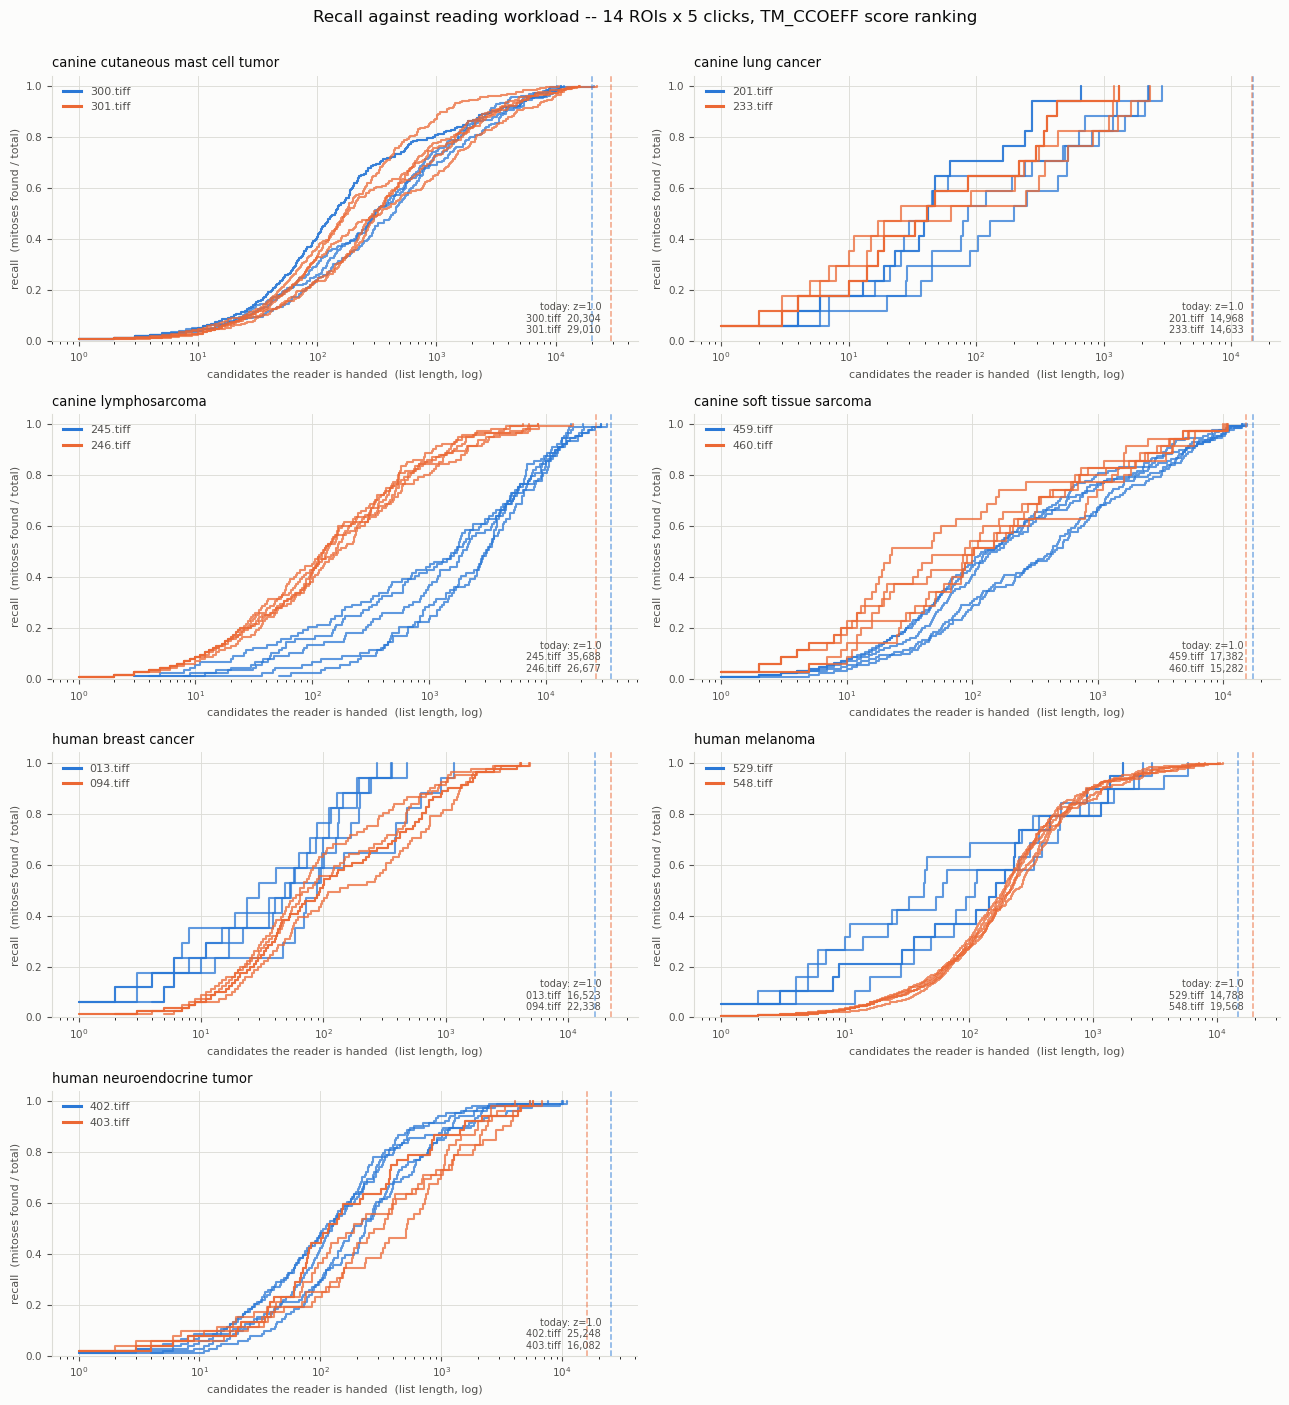


notebook total 12s | coverage_frac evaluated at 17,194 (cell, cutoff) pairs
At ~0.27 s per `evaluate.coverage_fraction` call that is 77 minutes of work, done once by `recall_workload_coverage.py` and read back here as a lookup.


In [11]:
SURFACE, INK, INK_2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#dcdcd6'
SERIES = ['#2a78d6', '#eb6834']       # categorical slots 1-2, validated as an all-pairs set

n, ncols = len(DOMAINS), 2
fig, axes = plt.subplots(-(-n // ncols), ncols, figsize=(13, 3.5 * -(-n // ncols)),
                         facecolor=SURFACE)
axes = np.atleast_1d(axes).ravel()

for ax, d in zip(axes, DOMAINS):
    ax.set_facecolor(SURFACE)
    rois = sorted({k[0] for k in KEYS if DOMAIN[k] == d})
    colour = {r: SERIES[i] for i, r in enumerate(rois)}
    for k in [k for k in KEYS if DOMAIN[k] == d]:
        m = int(cell_ix.loc[k, 'n_gt_mitotic'])
        # cost by n_at(z), matching every table -- not by rank, which a boundary score tie
        # would make an under-count (see `cutoff_for`).
        x = np.array([n_at(k, z_of(k, int(r))) for r in RANKS[k]])
        ax.step(x, np.arange(1, len(x) + 1) / m, where='post', color=colour[k[0]],
                linewidth=1.5, alpha=0.75, solid_capstyle='round')
    # One line per ROI, not one pooled median: over two ROIs a median is their midpoint, and
    # for `canine lymphosarcoma` that midpoint is ~4,500 candidates from either ROI.
    cur = {r: per_roi([k for k in KEYS if k[0] == r],
                      lambda k: float(cell_ix.loc[k, 'n_at_current_z']))[r] for r in rois}
    for r in rois:
        ax.axvline(cur[r], color=colour[r], linestyle='--', linewidth=1.1, alpha=0.6)
    ax.annotate('today: z=1.0\n' + '\n'.join(f'{r}  {cur[r]:,.0f}' for r in rois),
                xy=(max(cur.values()), 0.02), xytext=(-7, 0), textcoords='offset points',
                ha='right', va='bottom', fontsize=7, color=INK_2)
    for r in rois:                                     # direct labels, not colour alone
        ax.plot([], [], color=colour[r], linewidth=2.2, label=r)
    ax.set_xscale('log')
    ax.set_ylim(0, 1.04)
    ax.set_xlabel('candidates the reader is handed  (list length, log)', fontsize=8, color=INK_2)
    ax.set_ylabel('recall  (mitoses found / total)', fontsize=8, color=INK_2)
    ax.set_title(d, fontsize=9.5, color=INK, loc='left')
    ax.grid(True, which='major', color=GRID, linewidth=0.7, alpha=0.9)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_2, labelsize=7.5)
    ax.legend(fontsize=8, frameon=False, loc='upper left', labelcolor=INK_2,
              handlelength=1.6, borderaxespad=0.6)

for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('Recall against reading workload -- 14 ROIs x 5 clicks, TM_CCOEFF score ranking',
             fontsize=12, color=INK, y=1.0)
fig.tight_layout()
plt.show()
print(f'\nnotebook total {time.time() - NB_T0:.0f}s | coverage_frac evaluated at '
      f'{COV_CALLS:,} (cell, cutoff) pairs')
print(f'At ~0.27 s per `evaluate.coverage_fraction` call that is '
      f'{COV_CALLS * 0.27 / 60:.0f} minutes of work, done once by '
      f'`recall_workload_coverage.py` and read back here as a lookup.')

## Closing summary

**The gate first.** On the 7 ROIs shared with high_z, all 35 cells reproduce `z_max`,
`map_median`, `mad_scale`, `n_pool`, `n_at_current_z`, `base_size` and `seed_ann_id`
**bit-for-bit**, and `read_50 ... read_100` re-derived from ledger ranks matches
`compare._read_depths` in all 42 cells. Eight self-tests then check every one of the 6,555
mitoses individually. This is high_z, extended -- not a different pipeline that agrees.

**recall@K cannot pick this threshold.** Across 70 cells x 8 budgets x 3 cutoffs spanning
`[1.0, z_max]`, `recall_at_budget` on `tm_score` moved in **0 of 1,680** comparisons (1,120 of
them against a genuinely different cutoff). Below `z_max` every mitosis is inside the retained
prefix, so truncation deletes only non-TP tail and the top-K is unreachable.

**What moves recall@K is the ROI, not the click.** Decomposed rather than pooled, with the
per-ROI medians taken over distinct draws: the largest genuine **within-ROI click** spread
anywhere is **0.353** (lung cancer, K = 50); the largest **between-ROI** gap is **0.498**
(lymphosarcoma, K = 500), where the pooled 10-cell range that mixes the two axes reads 0.605.
The largest pooled range anywhere is 0.651 (lymphosarcoma, K = 1000) -- the number an earlier
version of this notebook reported as a "click spread".

**What one mitosis buys, on the detector's pool.** Quote the count-indexed table, not the
fractional one -- `ceil(0.99 x 17) = 17` costs a small ROI nothing. Pool cut is given as the
range over the 14 ROI medians, never as a pooled cell median:

| mitoses given up, per ROI | global `z` (shipped) | pool cut, 14 ROI medians | worst cell's list | `coverage_frac` |
|---|---|---|---|---|
| 0 | 1.3 | 6.5-17.9% (median 9.7%) | 36,251 | 0.666-0.994 |
| 1 | 1.6 | 13.8-29.1% (median 19.6%) | 31,852 | 0.624-0.979 |
| 2 | 1.7 | 16.0-32.5% (median 22.5%) | 29,926 | 0.613-0.966 |
| 5 | 2.0 | 22.9-45.9% (median 32.4%) | 23,346 | 0.583-0.923 |

One annotation roughly doubles the median pool cut. It barely touches the **worst** cell, which
is the one a pathologist experiences: 36,251 -> 31,852.

**And `coverage_frac` says not to read much into any of it.** At the shipped full-recall cutoff
the 14 ROI medians run **0.666-0.994**. `evaluate.py` is explicit that a list this saturated
answers "was this annotation found?" by geometry, so `recall_worst = 1.0000` in those rows is
close to the tautology this notebook's predecessor was audited for. The coverage of *the very
cell whose recall is quoted* decays alongside that recall above `z_max`: lymphosarcoma, whose
worst cell falls to recall 0.584 by `z = 3.0`, goes **0.998 -> 0.228** in coverage between
`z = 1.0` and `3.0`, while breast cancer, still at recall 1.000 there, goes **0.942 -> 0.665**.
That is the same domain ordering as the recall cliff. So "a global cutoff above 2 is a bet on
the domain" may be a bet on candidate *density* rather than on discriminability.

**Table 4 is where the real trade lives -- and only its shallow half is evidence.** A reading
depth is `min{K : recall@K >= t}`, the inverse of the curve coverage gates, so saturation makes
a depth read *shorter* than it should. Measured at every depth, both aggregations reported:

| target | median-ROI depth | median-ROI coverage | worst cell (D4) | *that cell's* coverage |
|---|---:|---:|---:|---:|
| 0.90 | 1,906 | **0.149** | 13,099 | 0.723 |
| 0.95 | 2,579 | **0.199** | 18,681 | 0.861 |
| 0.98 | 4,052 | 0.294 | 26,313 | 0.947 |
| 1.00 | 9,265 | 0.588 | 33,073 | 0.986 |

The two middle columns are separate medians over the 14 ROIs -- the median depth and the median
coverage need not come from the same ROI, so that pair is a summary and not a matched cell. The
worst-cell pair *is* matched: both numbers are `245.tiff`'s.

**Giving up 10% of mitoses cuts reading 4.9x at the median ROI and 2.5x at the worst cell**, and
those two rows are the only ones in this notebook whose coverage (0.149, 0.723) is low enough to
be about evidence rather than geometry. Full recall at the worst cell sits at coverage 0.986 and
means very little. Nothing about `z` does what Table 4 does, because `z` deletes the bottom of a
list that is read from the top: Tables 1/1b price a compute saving on a pool nobody reads,
Table 4 prices the clinical one -- at the median ROI, and half as well at the ROI D4 says to
quote.

**Transfer: three failures, all on one ROI.** Fitted on 6 domains and tested on the held-out
7th, the cutoff met its tolerance in **32 of 35** tests. On the shipped (floored) cutoffs
`transfer_gap_z` is 28 negative, 4 zero, **3 positive** -- and the 3 positive gaps are *exactly*
the 3 failures, which is what the arithmetic requires: a gap at or below zero puts the outside
cutoff at or under the domain's own, which meets `t` by construction. Transfer succeeded 32
times mostly because the outside cutoff was more conservative than the held-out domain needed --
a property of this 7-domain mixture, not a safety property.

The failures are all `canine lymphosarcoma`, and within it all on **`245.tiff`**. The worst is
severe: at t = 0.90 a cutoff the other six domains license delivers 0.730 on `245.tiff` s2 --
**24 mitoses lost against 8 budgeted, a 3.0x overrun**. Its `coverage_frac` is **0.392**, low
enough that this recall number is evidence rather than geometry, which makes the failure more
credible than most of the 32 successes: their `cov_roi_lo` is above 0.8 in only **9 of 32** rows
(median 0.738) and their `cov_roi_hi` in 24 of 32 (median 0.875). The t = 0.99 failure loses one
mitosis against a budget of **zero**, so its overrun is unbounded rather than 1.0x, and it sits
at coverage 0.982 -- that one is geometry.

LODO holds out a *domain* but each domain is 2 ROIs, so this is an **ROI**-transfer failure
surfacing as a domain one -- the same `245.tiff`/`246.tiff` split that dominates the click axis
at 4 of 5 tolerances and needs 8,502 against 29,455 candidates for full recall (1,632 against
12,622 at t = 0.90). One heterogeneity, three appearances.

**What this does not settle.**

* **A minimum still has no margin.** The tolerance axis relaxes only the innermost minimum, over
  mitoses; the aggregation across cells is still a hard min, and most global rows are set by one
  cell. D4's closing note names the machinery (conformal risk control) that would turn "this
  held on 14 ROIs" into a guarantee on an unseen slide.
* **63 distinct clicks, not 70.** The draw is with replacement, kept so the high_z gate stays
  meaningful. Every median here runs over distinct draws; `tm_variant_sweep.draw_seeds` draws
  without replacement and is the right rule for a run that does not need the gate.
* **Two ROIs per domain is not "worst ROI".** It is the first measurement of that axis, and the
  axis already dominates in 9 of 35 cells. It does not bound it. It also means nothing here
  medians across a domain's two ROIs -- with two values that is their midpoint, which for
  lymphosarcoma lands ~10,000 candidates from either ROI.
* **The tolerance is a clinical choice, not a statistic.** Table 4 prices "give up one mitosis
  in ten" at 4.9x less reading at the median ROI, 2.5x at the worst. Whether that is acceptable
  is a pathologist's call; this notebook's contribution is that it can be asked with a number
  attached.

## Corrections applied after two rounds of audit

`Research Logs/2026-09-08-tm-recall-workload-audit.md` (round 1) re-derived every table from the
stored artefacts and found the computation correct and the prose not.
`...-audit-round2.md` re-audited the fixes and found that they had been applied to the tables
round 1 named and not to the two sections written after it. Both sets are closed here.

**Round 1.**

1. **`coverage_frac` was never computed**, while Tables 1, 1b, 2 and LODO are all un-budgeted
   full-list recall -- exactly what `evaluate.py` requires it for. Now reported in every one of
   them, via `recall_workload_coverage.py`.
2. **Pooled 10-cell medians landed in the gap between the two ROIs** and described no cell that
   existed. Aggregation is per ROI (`per_roi`), then reported as a range across ROIs.
3. **`click_spread` was mostly an ROI spread**, overstating the click by ~2x. Decomposed.
4. **Four false statements**: the LODO overrun was 3x not 2x (8 budgeted, not 12);
   `transfer_gap_z` is 28 negative on the shipped column, not 30; a positive exact gap also
   occurs on soft tissue sarcoma without failing, so the gap column is now explicitly the
   shipped one; and the ROI axis dominates at 4 of 5 tolerances in two domains and 1 of 5 in a
   third, not "throughout" -- enumerated in the cell now.
5. **The stated justification for integer `ceil` was fabricated** -- `0.99*100` is exactly 99.0
   and the float form never disagrees. Deleted; the code is kept as belt-and-braces.
6. **Duplicate draws got double weight in medians.** Every median is over distinct draws.
7. **Latent code issues**: `count_row` blanked whole group rows; LODO guarded only one cell
   list; the figure costed by `rank`; the recall@K denominator counted 560 self-comparisons.

**Round 2.**

8. **Table 4 was exempted from the coverage gate by argument, not measurement** -- and the
   argument was wrong in the flattering direction, since a depth is the *inverse* of the gated
   curve. Coverage is now measured at every depth, and it shows the exemption holds only for
   the shallow rows.
9. **Table 4's headline was a median-ROI number** in a notebook whose rule is worst ROI, worst
   click. Both are now computed and quoted; the worst-cell saving is about half.
10. **Table 4's per-domain block medianed exactly two ROIs**, i.e. printed their midpoint --
    round-1 defect #2 re-created one level up. It prints `roi_lo`/`roi_hi` now, and `per_roi`
    documents the trap. The figure's dashed `z = 1.0` line had the same shape and is now one
    line per ROI in that ROI's colour.
11. **Table 3's `roi_gap` was the one median still double-counting repeated draws** (it changed
    in 27 of 56 (domain, K) cells). It goes through `per_roi` now.
12. **The summary quoted a pooled range from a different budget** than the gap it sat beside
    (0.651 at K = 1000 against a gap at K = 500). Both budgets are now named.
13. **Table 2 lined up a min-recall cell with a max-coverage cell** under one "worst cell"
    heading. It now reports the coverage of the very cell whose recall is quoted, alongside the
    most-saturated cell as a separate column -- and, since below `z_max` all 70 cells tie at
    recall 1.000, the tie is broken by highest coverage so the column never reports an arbitrary
    cell as the group's worst.
14. **"Coverage mostly above 0.8" leaned on the more flattering of two printed columns.** Both
    are now counted explicitly (9/32 and 24/32).
15. **`overrun_x` printed an unbounded overrun as "1.0x"** via a `max(budget, 1)` denominator.
    It reports `inf` now.
16. **`recall_workload_coverage.py` gated one point per curve** while claiming per-cell
    verification, and its cost justification (5.4 s, 840 pairs) was wrong in both directions.
    It gates four points per curve now, and the true figures -- ~0.27 s per call, and the call
    count this notebook prints for itself at the end of the run -- are in the docstring.